# PHẦN 2 - Thay đổi các tham số và quan sát kết quả

Mục tiêu: Thay đổi các tham số của Canny để xem ảnh hưởng đến kết quả phát hiện cạnh.

Tính năng:
- Thay đổi ngưỡng thấp và ngưỡng cao trong OpenCV Canny.
- Thay đổi `sigma` trong Scikit-image Canny.
- Đếm số điểm cạnh.
- Đo thời gian xử lý.
- So sánh kết quả với giá trị mặc định.

In [1]:
import os
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import canny as skimage_canny

os.makedirs("../output", exist_ok=True)

img_bgr = cv2.imread("../input/demo.jpg")

if img_bgr is None:
    raise FileNotFoundError("Không tìm thấy ảnh tại ../input/demo.jpg")

img_bgr = cv2.resize(img_bgr, (512, 512), interpolation=cv2.INTER_AREA)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
gray_f = img_gray.astype(np.float64) / 255.0

print("Đọc ảnh thành công!")
print("Kích thước ảnh:", img_bgr.shape)

Matplotlib is building the font cache; this may take a moment.


Đọc ảnh thành công!
Kích thước ảnh: (512, 512, 3)


# Thay đổi ngưỡng thấp và ngưỡng cao

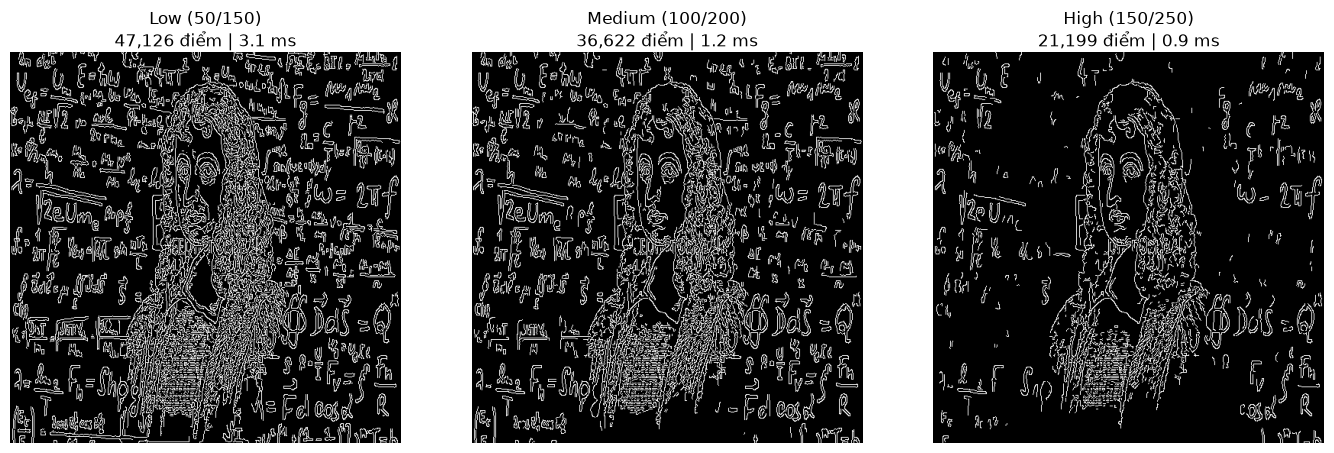

In [2]:
fig1, axes1 = plt.subplots(1, 3, figsize=(14, 4.5))

threshold_list = [
    (50, 150, "Low (50/150)"),
    (100, 200, "Medium (100/200)"),
    (150, 250, "High (150/250)")
]

for ax, (lo, hi, label) in zip(axes1, threshold_list):
    t0 = time.perf_counter()

    edge = cv2.Canny(img_gray, lo, hi)

    time_run = (time.perf_counter() - t0) * 1000
    points = int(np.sum(edge > 0))

    ax.imshow(edge, cmap="gray")
    ax.set_title(f"{label}\n{points:,} điểm | {time_run:.1f} ms", pad=4)
    ax.axis("off")

plt.tight_layout()
plt.savefig("../output/05_compare_threshold_opencv.png", dpi=150)
plt.show()

# Thay đổi sigma

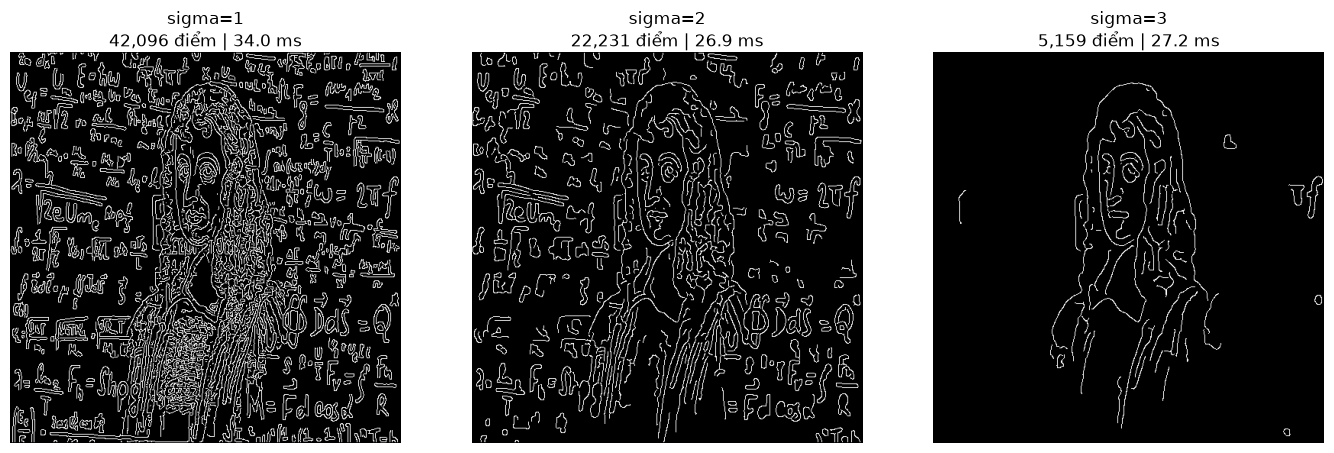

In [3]:
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4.5))

sigma_list = [1, 2, 3]

for ax, sigma in zip(axes2, sigma_list):
    t0 = time.perf_counter()

    edge = skimage_canny(gray_f, sigma=sigma)

    time_run = (time.perf_counter() - t0) * 1000
    points = int(np.sum(edge))

    edge_uint8 = edge.astype(np.uint8) * 255

    ax.imshow(edge_uint8, cmap="gray")
    ax.set_title(f"sigma={sigma}\n{points:,} điểm | {time_run:.1f} ms", pad=4)
    ax.axis("off")

plt.tight_layout()
plt.savefig("../output/06_compare_sigma_skimage.png", dpi=150)
plt.show()

# So sánh giá trị mặc định

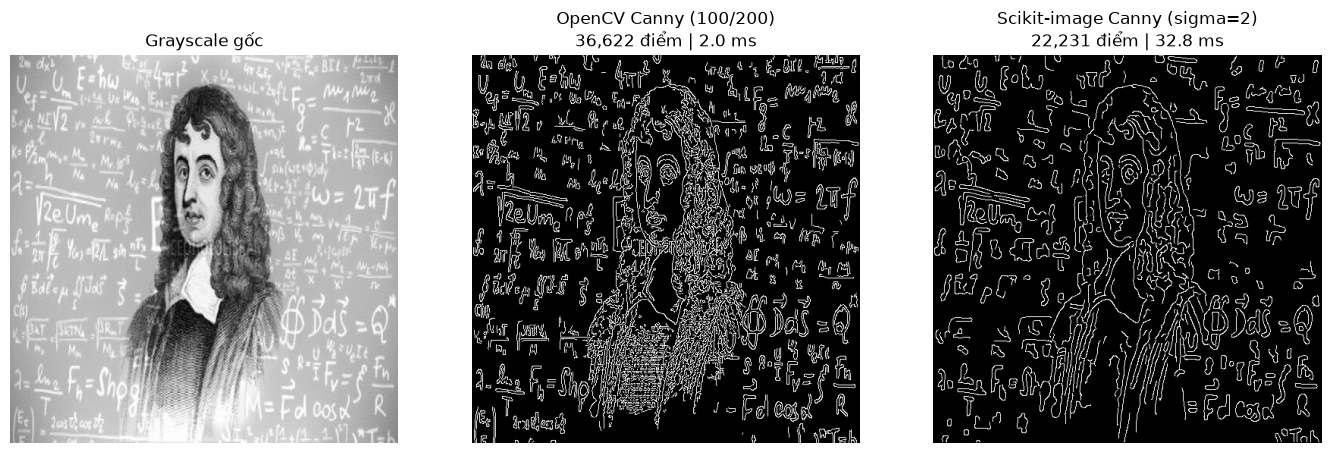

In [4]:
fig3, axes3 = plt.subplots(1, 3, figsize=(14, 4.5))

# OpenCV Canny mặc định
t0 = time.perf_counter()
edge_cv2 = cv2.Canny(img_gray, 100, 200)
time_cv2 = (time.perf_counter() - t0) * 1000
points_cv2 = int(np.sum(edge_cv2 > 0))

# Scikit-image Canny với sigma = 2
t0 = time.perf_counter()
edge_ski = skimage_canny(gray_f, sigma=2)
time_ski = (time.perf_counter() - t0) * 1000
points_ski = int(np.sum(edge_ski))

edge_ski_uint8 = edge_ski.astype(np.uint8) * 255

axes3[0].imshow(img_gray, cmap="gray")
axes3[0].set_title("Grayscale gốc")
axes3[0].axis("off")

axes3[1].imshow(edge_cv2, cmap="gray")
axes3[1].set_title(f"OpenCV Canny (100/200)\n{points_cv2:,} điểm | {time_cv2:.1f} ms")
axes3[1].axis("off")

axes3[2].imshow(edge_ski_uint8, cmap="gray")
axes3[2].set_title(f"Scikit-image Canny (sigma=2)\n{points_ski:,} điểm | {time_ski:.1f} ms")
axes3[2].axis("off")

plt.tight_layout()
plt.savefig("../output/07_compare_default_value.png", dpi=150)
plt.show()